# ch272 — Data Cleaning

*(Building on ch271 — Data and Measurement: measurement error is the root cause of most data quality problems.)*

## 1. Why Cleaning Matters

Garbage in, garbage out is not a metaphor. It is a mathematical fact: every estimator, test, and model assumes the input data meets certain conditions. When those conditions are violated — missing values, duplicates, outliers, inconsistent encoding — the estimator's guarantees break down.

Data cleaning is not preprocessing. It is the act of constructing a dataset whose properties match the assumptions of the analysis you intend to run.

---

## 2. The Five Classes of Data Problems

| Problem | Definition | Effect on analysis |
|---|---|---|
| **Missing values** | NaN, None, sentinel values | Biases estimates if not missing completely at random |
| **Duplicates** | Identical or near-identical rows | Inflates sample size, biases toward repeated records |
| **Outliers** | Extreme values relative to the distribution | Distorts mean, regression coefficients, covariance |
| **Encoding inconsistency** | 'US', 'usa', 'United States' as three categories | Creates spurious categories, reduces effective N |
| **Type errors** | '42.5' stored as string | Prevents arithmetic; produces silent errors |

---

## 3. Setup: A Deliberately Dirty Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
n = 200

# Ground truth
age      = rng.integers(18, 65, size=n).astype(float)
revenue  = 50 + 3 * age + rng.normal(0, 20, n)  # linear relationship + noise
country  = rng.choice(['US', 'UK', 'DE', 'FR'], n)

# --- Inject problems ---

# 1. Missing values (10%)
missing_age = rng.choice(n, 20, replace=False)
missing_rev = rng.choice(n, 20, replace=False)
age[missing_age] = np.nan
revenue[missing_rev] = np.nan

# 2. Outliers: a few extreme revenue values
outlier_idx = rng.choice(n, 5, replace=False)
revenue[outlier_idx] = rng.uniform(2000, 5000, 5)

# 3. Duplicates: copy 10 rows
dup_idx = rng.choice(n, 10, replace=False)
age_full    = np.concatenate([age,    age[dup_idx]])
revenue_full = np.concatenate([revenue, revenue[dup_idx]])
country_full = np.concatenate([country, country[dup_idx]])

# 4. Encoding inconsistency
raw_country = country_full.copy()
fix_idx = rng.choice(len(raw_country), 15, replace=False)
raw_country[fix_idx[:5]]   = 'us'
raw_country[fix_idx[5:10]] = 'United States'
raw_country[fix_idx[10:]]  = ' DE'

print(f"Raw dataset: {len(age_full)} rows (includes {10} duplicates)")
print(f"Missing age: {np.isnan(age_full).sum()}")
print(f"Missing revenue: {np.isnan(revenue_full).sum()}")
print(f"Outlier revenue values (>500): {np.sum(revenue_full[~np.isnan(revenue_full)] > 500)}")
unique, counts = np.unique(raw_country, return_counts=True)
print(f"\nRaw country encoding: {dict(zip(unique, counts))}")

Raw dataset: 210 rows (includes 10 duplicates)
Missing age: 21
Missing revenue: 22
Outlier revenue values (>500): 5

Raw country encoding: {np.str_(' D'): np.int64(5), np.str_('DE'): np.int64(54), np.str_('FR'): np.int64(50), np.str_('UK'): np.int64(46), np.str_('US'): np.int64(45), np.str_('Un'): np.int64(5), np.str_('us'): np.int64(5)}


## 4. Handling Missing Values

Three mechanisms govern missingness — the choice of handling method depends on which applies:

- **MCAR** (Missing Completely At Random): missingness unrelated to any variable. Listwise deletion is valid but wastes data.
- **MAR** (Missing At Random): missingness depends on observed variables. Imputation is valid.
- **MNAR** (Missing Not At Random): missingness depends on the unobserved value itself (e.g., high earners not reporting income). No imputation is truly valid; requires domain knowledge.

Common imputation strategies:

| Strategy | When valid | Risk |
|---|---|---|
| Listwise deletion | MCAR, low missingness | Reduces N |
| Mean/median imputation | MCAR, continuous | Distorts variance, covariance |
| Conditional mean | MAR | Requires a model |
| Multiple imputation | MAR | Computationally heavier |

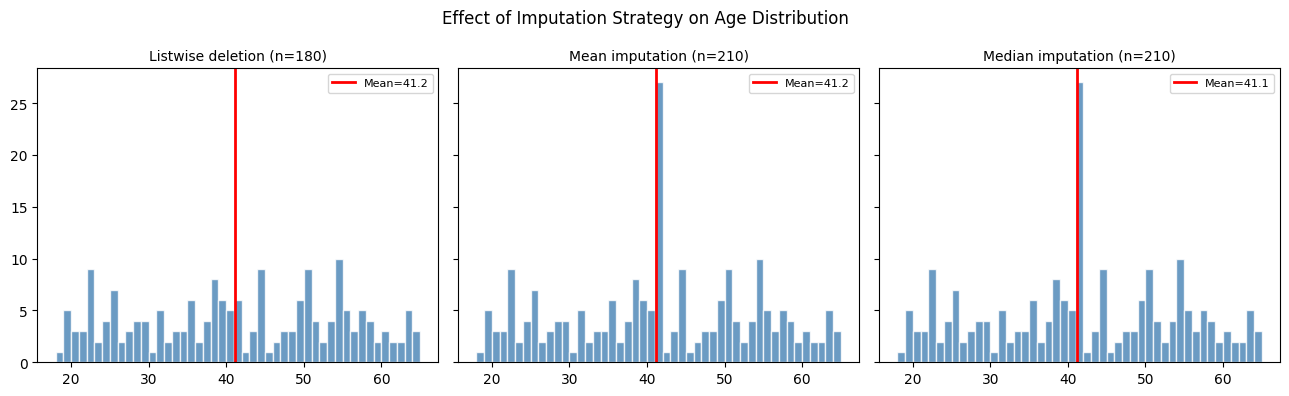

Mean imputation: creates a spike at the mean, suppresses variance.
Downstream covariance estimates will be biased downward.


In [2]:
def impute_mean(arr: np.ndarray) -> np.ndarray:
    """Replace NaN with column mean (assumes MCAR)."""
    result = arr.copy()
    mask = np.isnan(result)
    result[mask] = np.nanmean(result)
    return result

def impute_median(arr: np.ndarray) -> np.ndarray:
    """Replace NaN with column median."""
    result = arr.copy()
    result[np.isnan(result)] = np.nanmedian(result)
    return result

# Compare effect on distribution
age_mean_imp   = impute_mean(age_full)
age_median_imp = impute_median(age_full)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
bins = np.arange(18, 66)

for ax, data, label in zip(axes,
    [age_full[~np.isnan(age_full)], age_mean_imp, age_median_imp],
    ['Listwise deletion (n=180)', 'Mean imputation (n=210)', 'Median imputation (n=210)']):
    ax.hist(data, bins=bins, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(np.nanmean(data), color='red', lw=2, label=f'Mean={np.nanmean(data):.1f}')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Effect of Imputation Strategy on Age Distribution', fontsize=12)
plt.tight_layout()
plt.show()

print("Mean imputation: creates a spike at the mean, suppresses variance.")
print("Downstream covariance estimates will be biased downward.")

## 5. Removing Duplicates

In [3]:
def deduplicate(arrays: list[np.ndarray]) -> list[np.ndarray]:
    """
    Remove rows where all features are identical.
    Returns deduplicated arrays and the boolean mask of kept rows.
    """
    # Stack into a matrix for row-wise comparison
    # Handle NaN by treating np.nan == np.nan as True (for dedup purposes)
    n_rows = len(arrays[0])
    seen   = set()
    keep   = np.ones(n_rows, dtype=bool)

    for i in range(n_rows):
        key = tuple(float(a[i]) if not isinstance(a[i], str) else a[i] for a in arrays)
        if key in seen:
            keep[i] = False
        else:
            seen.add(key)

    return [a[keep] for a in arrays], keep

arrays_clean, keep_mask = deduplicate([age_full, revenue_full, raw_country])
age_dedup, revenue_dedup, country_dedup = arrays_clean

print(f"Before dedup: {len(age_full)} rows")
print(f"After  dedup: {len(age_dedup)} rows")
print(f"Removed: {len(age_full) - len(age_dedup)} duplicates")

Before dedup: 210 rows
After  dedup: 203 rows
Removed: 7 duplicates


## 6. Detecting and Handling Outliers

An outlier is not automatically an error. It may be:
- A measurement error → remove it
- An extreme but valid observation → keep it, use robust statistics
- A data entry error → correct it if possible

Two standard detection methods:
1. **IQR rule**: flag values below Q1 − 1.5·IQR or above Q3 + 1.5·IQR
2. **Z-score rule**: flag values with |z| > 3 (assumes near-normal distribution)

IQR rule flags    5 outliers
Z-score rule flags 5 outliers


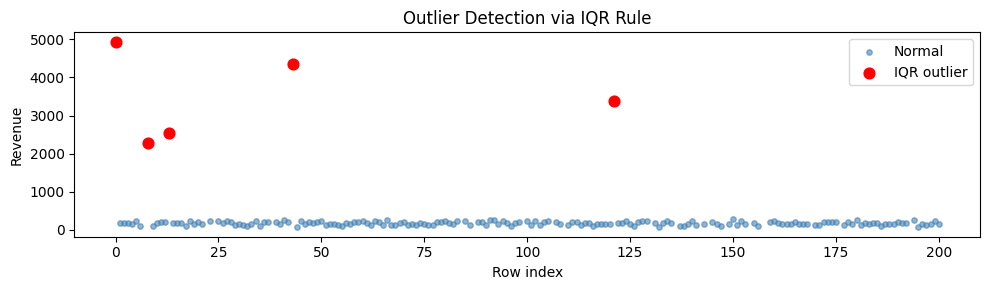


Before winsorize: max=4940, mean=266.2
After  winsorize: max=3571, mean=254.5


In [4]:
def flag_outliers_iqr(arr: np.ndarray, k: float = 1.5) -> np.ndarray:
    """Returns boolean mask: True where value is an outlier."""
    clean = arr[~np.isnan(arr)]
    q1, q3 = np.percentile(clean, [25, 75])
    iqr = q3 - q1
    return (arr < q1 - k * iqr) | (arr > q3 + k * iqr)

def flag_outliers_zscore(arr: np.ndarray, threshold: float = 3.0) -> np.ndarray:
    """Returns boolean mask: True where |z-score| > threshold."""
    mean = np.nanmean(arr)
    std  = np.nanstd(arr)
    z    = (arr - mean) / std
    return np.abs(z) > threshold

rev = revenue_dedup
iqr_mask    = flag_outliers_iqr(rev)
zscore_mask = flag_outliers_zscore(rev)

print(f"IQR rule flags    {iqr_mask.sum()} outliers")
print(f"Z-score rule flags {zscore_mask.sum()} outliers")

fig, ax = plt.subplots(figsize=(10, 3))
valid = ~np.isnan(rev)
ax.scatter(np.where(valid)[0], rev[valid], s=15, color='steelblue', alpha=0.6, label='Normal')
ax.scatter(np.where(iqr_mask)[0], rev[iqr_mask], s=60, color='red', zorder=5, label='IQR outlier')
ax.set_xlabel('Row index'); ax.set_ylabel('Revenue')
ax.set_title('Outlier Detection via IQR Rule')
ax.legend()
plt.tight_layout()
plt.show()

# Winsorize as an alternative to removal
def winsorize(arr: np.ndarray, lower: float = 1.0, upper: float = 99.0) -> np.ndarray:
    """Clip values at given percentiles."""
    lo, hi = np.nanpercentile(arr, [lower, upper])
    return np.clip(arr, lo, hi)

rev_winsorized = winsorize(rev)
print(f"\nBefore winsorize: max={np.nanmax(rev):.0f}, mean={np.nanmean(rev):.1f}")
print(f"After  winsorize: max={np.nanmax(rev_winsorized):.0f}, mean={np.nanmean(rev_winsorized):.1f}")

## 7. Encoding Standardization

In [5]:
COUNTRY_MAP = {
    'us':            'US',
    'united states': 'US',
    'usa':           'US',
    'uk':            'UK',
    'united kingdom':'UK',
    'de':            'DE',
    'germany':       'DE',
    'fr':            'FR',
    'france':        'FR',
}

def standardize_country(arr: np.ndarray) -> np.ndarray:
    """Normalize country strings to canonical 2-letter codes."""
    result = np.empty_like(arr)
    for i, val in enumerate(arr):
        key = str(val).strip().lower()
        result[i] = COUNTRY_MAP.get(key, val.strip().upper())
    return result

country_clean = standardize_country(country_dedup)

raw_unique, raw_counts = np.unique(country_dedup, return_counts=True)
cln_unique, cln_counts = np.unique(country_clean, return_counts=True)

print("Before standardization:", dict(zip(raw_unique, raw_counts)))
print("After  standardization:", dict(zip(cln_unique, cln_counts)))

Before standardization: {np.str_(' D'): np.int64(5), np.str_('DE'): np.int64(53), np.str_('FR'): np.int64(48), np.str_('UK'): np.int64(43), np.str_('US'): np.int64(44), np.str_('Un'): np.int64(5), np.str_('us'): np.int64(5)}
After  standardization: {np.str_('D'): np.int64(5), np.str_('DE'): np.int64(53), np.str_('FR'): np.int64(48), np.str_('UK'): np.int64(43), np.str_('UN'): np.int64(5), np.str_('US'): np.int64(49)}


## 8. A Cleaning Pipeline

In [6]:
def clean_dataset(
    age_raw: np.ndarray,
    revenue_raw: np.ndarray,
    country_raw: np.ndarray,
) -> dict:
    """
    Full cleaning pipeline:
    1. Deduplicate
    2. Standardize encoding
    3. Flag and winsorize outliers
    4. Median-impute missing values
    Returns a dict of cleaned arrays and a cleaning report.
    """
    report = {}
    n0 = len(age_raw)

    # Step 1
    (age, revenue, country), _ = deduplicate([age_raw, revenue_raw, country_raw])
    report['duplicates_removed'] = n0 - len(age)

    # Step 2
    country = standardize_country(country)

    # Step 3
    revenue_iqr_outliers = flag_outliers_iqr(revenue).sum()
    revenue = winsorize(revenue)
    report['revenue_outliers_winsorized'] = int(revenue_iqr_outliers)

    # Step 4
    report['missing_age_imputed'] = int(np.isnan(age).sum())
    report['missing_revenue_imputed'] = int(np.isnan(revenue).sum())
    age     = impute_median(age)
    revenue = impute_median(revenue)

    report['final_n'] = len(age)
    return {'age': age, 'revenue': revenue, 'country': country}, report

cleaned, report = clean_dataset(age_full, revenue_full, raw_country)

print("=== Cleaning Report ===")
for k, v in report.items():
    print(f"  {k}: {v}")

print(f"\nFinal dataset: {report['final_n']} rows, 0 NaN")
print(f"NaN in age:    {np.isnan(cleaned['age']).sum()}")
print(f"NaN in revenue:{np.isnan(cleaned['revenue']).sum()}")

=== Cleaning Report ===
  duplicates_removed: 7
  revenue_outliers_winsorized: 5
  missing_age_imputed: 21
  missing_revenue_imputed: 22
  final_n: 203

Final dataset: 203 rows, 0 NaN
NaN in age:    0
NaN in revenue:0


## 9. What Comes Next

With a clean dataset, you can compute meaningful summaries. **ch273 — Descriptive Statistics** formalizes mean, median, variance, skewness, and their relationships. The outlier effects you observed in section 6 will reappear there quantitatively.

The imputation choices made here propagate through every downstream analysis. In **ch276 — Bias and Variance**, you will see that mean imputation specifically inflates the bias of covariance estimates — a concrete consequence of the design choice made in this chapter.